# Stage 06 — Power & Minimum Detectable Effect Analysis

Statistical power is the probability of detecting a specified non-null effect under a chosen design; Type II error is the probability of not detecting such an effect. The minimum detectable effect (MDE) is the smallest effect a design can detect with a chosen power. Power analysis supports experiment design by connecting alpha, sample size, variability or baseline rate, and a target effect.

Prospective power is useful before an experiment. Observed-effect post-hoc power is often redundant with the hypothesis-test result, so this notebook focuses instead on MDE at the actual sample size, required future sample sizes for meaningful hypothetical effects, and sensitivity curves.

## 1. Experiment design and planning principles

Control: No E-Mail. Treatments: Mens E-Mail and Womens E-Mail. Observed sample sizes are 21,306, 21,307, and 21,387 respectively. Primary comparisons are each treatment versus control. Calculations use two-sided alpha = 0.05 and target powers of 80% and 90%, consistent with Stages 04 and 05.

Power rises with sample size and target effect size, and falls as the desired power becomes more stringent. Lower baseline event rates make small absolute changes difficult to detect. Absolute effects are percentage-point changes; relative lift is the percentage change relative to the baseline rate.

In [1]:
from hashlib import sha256
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from src.power_analysis import (
    binary_mde,
    mde_curve,
    required_binary_sample_size,
    spend_simulation_power,
)

project_root = Path('.')
if not (project_root / 'data/processed/Hillstrom_clean.csv').exists():
    project_root = Path('..')
raw_path = project_root / 'data/raw/Hillstrom.csv'
processed_path = project_root / 'data/processed/Hillstrom_clean.csv'
stage05_results_path = project_root / 'outputs/tables/primary_treatment_effects.csv'
figure_dir = project_root / 'outputs/figures'
table_dir = project_root / 'outputs/tables'
control_group = 'No E-Mail'
treatment_groups = ['Mens E-Mail', 'Womens E-Mail']
group_order = [control_group, *treatment_groups]
alpha = 0.05
target_powers = [0.80, 0.90]
simulation_seed = 20260918
monte_carlo_simulations = 1000

def file_sha256(path):
    return sha256(path.read_bytes()).hexdigest()

raw_hash_before = file_sha256(raw_path)
processed_hash_before = file_sha256(processed_path)
data = pd.read_csv(processed_path)
stage05_results = pd.read_csv(stage05_results_path)
control_data = data.loc[data['segment'] == control_group]
sample_sizes = data['segment'].value_counts().reindex(group_order)
print('Observed group sizes:')
display(sample_sizes.to_frame('Sample Size'))

Observed group sizes:


,Sample Size
segment,
No E-Mail,21306
Mens E-Mail,21307
Womens E-Mail,21387


## 2. Control baselines

Exact No E-Mail values are used as planning baselines because they represent the observed control population. They are estimates from this dataset, not immutable population parameters.

In [2]:
control_conversion_rate = control_data['conversion'].mean()
control_visit_rate = control_data['visit'].mean()
control_mean_spend = control_data['spend'].mean()
control_spend_sd = control_data['spend'].std(ddof=1)
control_zero_spend_rate = (control_data['spend'] == 0).mean()
control_positive_spend_rate = (control_data['spend'] > 0).mean()
control_positive_spend = control_data.loc[control_data['spend'] > 0, 'spend'].to_numpy()
control_positive_spend_mean = control_positive_spend.mean()
baseline_summary = pd.DataFrame([
    ['Control conversion rate', control_conversion_rate],
    ['Control visit rate', control_visit_rate],
    ['Control mean spend', control_mean_spend],
    ['Control spend standard deviation', control_spend_sd],
    ['Control spend coefficient of variation', control_spend_sd / control_mean_spend],
    ['Control zero-spend proportion', control_zero_spend_rate],
    ['Control positive-spend rate', control_positive_spend_rate],
], columns=['Baseline metric', 'Value'])
display(baseline_summary.round(6))

,Baseline metric,Value
0,Control conversion rate,0.005726
1,Control visit rate,0.106167
2,Control mean spend,0.652789
3,Control spend standard deviation,11.588200
4,Control spend coefficient of variation,17.751821
5,Control zero-spend proportion,0.994274
6,Control positive-spend rate,0.005726


## 3. Binary-outcome MDE method

For a binary outcome, the calculation solves for Cohen h at the observed treatment/control sample-size ratio using a two-sample normal approximation, then converts h to a positive treatment rate. Slight treatment-size differences are retained; their resulting MDEs are expected to be nearly identical. MDE is reported as an absolute percentage-point increase and relative lift, not as a significance threshold for an observed estimate.

In [3]:
mde_rows = []
for outcome, baseline_rate in [('Conversion', control_conversion_rate), ('Visit', control_visit_rate)]:
    for treatment_group in treatment_groups:
        for target_power in target_powers:
            result = binary_mde(baseline_rate, sample_sizes[control_group], sample_sizes[treatment_group], target_power)
            result.update({'Outcome': outcome, 'Treatment Comparison': '{} vs {}'.format(treatment_group, control_group)})
            mde_rows.append(result)
mde_actual = pd.DataFrame(mde_rows)
display(mde_actual[['Outcome', 'Treatment Comparison', 'Power', 'Baseline Rate', 'MDE Percentage Points', 'Detectable Treatment Rate', 'Relative MDE']].round(6))

,Outcome,Treatment Comparison,Power,Baseline Rate,MDE Percentage Points,Detectable Treatment Rate,Relative MDE
0,Conversion,Mens E-Mail vs No E-Mail,0.8,0.005726,0.222986,0.007956,0.389422
1,Conversion,Mens E-Mail vs No E-Mail,0.9,0.005726,0.261311,0.008339,0.456352
2,Conversion,Womens E-Mail vs No E-Mail,0.8,0.005726,0.222761,0.007954,0.389028
3,Conversion,Womens E-Mail vs No E-Mail,0.9,0.005726,0.261043,0.008337,0.455884
4,Visit,Mens E-Mail vs No E-Mail,0.8,0.106167,0.850549,0.114673,0.080114
5,Visit,Mens E-Mail vs No E-Mail,0.9,0.106167,0.986747,0.116035,0.092943
6,Visit,Womens E-Mail vs No E-Mail,0.8,0.106167,0.849740,0.114665,0.080038
7,Visit,Womens E-Mail vs No E-Mail,0.9,0.106167,0.985804,0.116025,0.092854


## 4. Conversion and visit MDEs at the actual sample size

The table above reports the actual-size MDEs for both treatment comparisons at 80% and 90% power. Higher target power raises the MDE at fixed sample size because the design needs a larger signal to meet the stricter detection probability.

## 5. Required future sample size for binary outcomes

The following calculations assume equal-sized future treatment and control groups, two-sided alpha = 0.05, and the observed control baselines. They are design scenarios, not estimates of a future campaign effect.

In [4]:
conversion_effect_grid = np.array([0.001, 0.002, 0.003, 0.005, 0.0075, 0.010])
visit_effect_grid = np.array([0.005, 0.010, 0.020, 0.030, 0.050])
planning_rows = []
for outcome, baseline_rate, effect_grid in [('Conversion', control_conversion_rate, conversion_effect_grid), ('Visit', control_visit_rate, visit_effect_grid)]:
    for absolute_effect in effect_grid:
        for target_power in target_powers:
            planning_rows.append({'Outcome': outcome, 'Baseline': baseline_rate, 'Target Absolute Effect': absolute_effect, 'Target Relative Lift': absolute_effect / baseline_rate, 'Power': target_power, 'Alpha': alpha, 'Required Sample Size Per Group': required_binary_sample_size(baseline_rate, absolute_effect, target_power, alpha)})
planning_table = pd.DataFrame(planning_rows)
planning_table['Required Sample Size Per Group'] = planning_table['Required Sample Size Per Group'].round().astype(int)
display(planning_table.round(6))

,Outcome,Baseline,Target Absolute Effect,Target Relative Lift,Power,Alpha,Required Sample Size Per Group
0,Conversion,0.005726,0.0010,0.174639,0.8,0.05,96971
1,Conversion,0.005726,0.0010,0.174639,0.9,0.05,129816
2,Conversion,0.005726,0.0020,0.349279,0.8,0.05,26073
3,Conversion,0.005726,0.0020,0.349279,0.9,0.05,34905
4,Conversion,0.005726,0.0030,0.523918,0.8,0.05,12377
5,Conversion,0.005726,0.0030,0.523918,0.9,0.05,16569
6,Conversion,0.005726,0.0050,0.873197,0.8,0.05,5002
7,Conversion,0.005726,0.0050,0.873197,0.9,0.05,6697
8,Conversion,0.005726,0.0075,1.309795,0.8,0.05,2513
9,Conversion,0.005726,0.0075,1.309795,0.9,0.05,3364


## 6. MDE sensitivity curves

Curves show the positive absolute effect detectable at each equal per-group sample size for 80% and 90% power. Effects are displayed in percentage points.

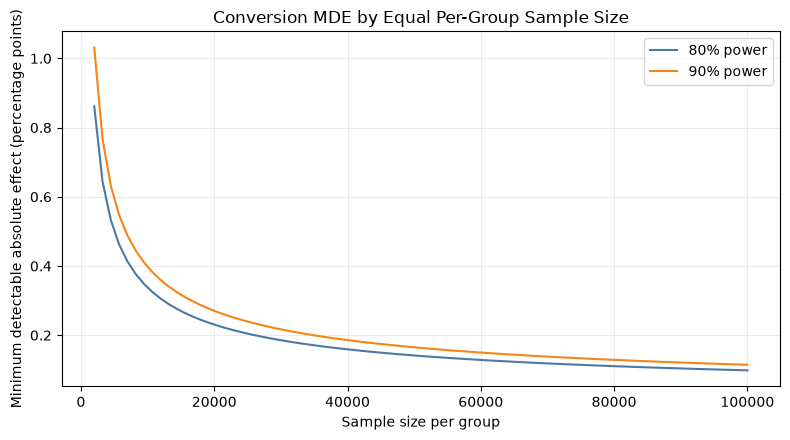

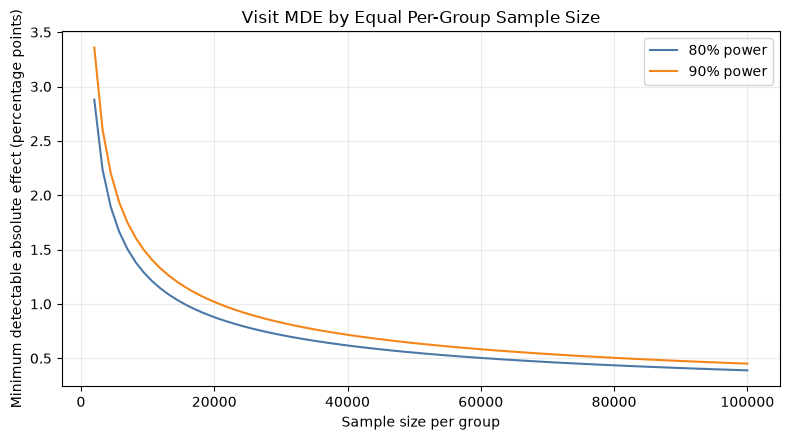

In [5]:
sample_size_grid = np.linspace(2000, 100000, 80).astype(int)
for outcome, baseline_rate, filename in [('Conversion', control_conversion_rate, 'conversion_mde_curve.png'), ('Visit', control_visit_rate, 'visit_mde_curve.png')]:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    for target_power, color in zip(target_powers, ['#4C78A8', '#F58518']):
        ax.plot(sample_size_grid, mde_curve(baseline_rate, sample_size_grid, target_power), label='{}% power'.format(int(target_power * 100)), color=color)
    ax.set(title='{} MDE by Equal Per-Group Sample Size'.format(outcome), xlabel='Sample size per group', ylabel='Minimum detectable absolute effect (percentage points)')
    ax.grid(alpha=0.25)
    ax.legend()
    plt.tight_layout()
    fig.savefig(figure_dir / filename, dpi=160, bbox_inches='tight')
    plt.show()

## 7. Observed Stage 05 effects as reference

Stage 05 observed absolute effects are used only as reference points against the design MDEs. An effect above the MDE helps explain why the design may have sensitivity to that magnitude; an effect below MDE is not necessarily zero or unimportant. MDE is not an observed-effect significance threshold.

In [6]:
observed_binary_effects = stage05_results.loc[stage05_results['Outcome'].isin(['Conversion', 'Visit']), ['Outcome', 'Treatment', 'Absolute Effect']].copy()
observed_binary_effects['Observed Effect (percentage points)'] = observed_binary_effects['Absolute Effect'] * 100
reference_mde = mde_actual.loc[mde_actual['Power'] == 0.80, ['Outcome', 'Treatment Comparison', 'MDE Percentage Points']].copy()
reference_mde['Treatment'] = reference_mde['Treatment Comparison'].str.replace(' vs No E-Mail', '', regex=False)
comparison_with_mde = observed_binary_effects.merge(reference_mde[['Outcome', 'Treatment', 'MDE Percentage Points']], on=['Outcome', 'Treatment'])
display(comparison_with_mde.round(4))

,Outcome,Treatment,Absolute Effect,Observed Effect (percentage points),MDE Percentage Points
0,Conversion,Mens E-Mail,0.0068,0.6805,0.2230
1,Conversion,Womens E-Mail,0.0031,0.3111,0.2228
2,Visit,Mens E-Mail,0.0766,7.6590,0.8505
3,Visit,Womens E-Mail,0.0452,4.5233,0.8497


## 8. Spend distribution and simulation design

Spend power is more complicated than binary-outcome power because it is approximately 99% zero, strongly right-skewed, and heavy-tailed. A simple normal-theory calculation would not be exact. The simulation below preserves the empirical control positive-spend distribution. In each scenario, control positive-spend probability remains empirical; treatment positive-spend probability rises by the target mean-spend increase divided by the empirical control mean positive spend. Positive spend amounts are resampled from the empirical control positive-spend values. This approximately preserves zero inflation and defines a transparent scenario, but it is not an exact prediction of a future treatment mechanism.

In [7]:
spend_effect_grid = np.array([0.10, 0.25, 0.50, 0.75, 1.00])
simulation_rng = np.random.default_rng(simulation_seed)
spend_simulation_rows = []
for mean_effect in spend_effect_grid:
    simulation_result = spend_simulation_power(
        mean_effect,
        simulation_rng,
        control_n=sample_sizes[control_group],
        treatment_n=sample_sizes['Mens E-Mail'],
        control_positive_spend_rate=control_positive_spend_rate,
        control_positive_spend_mean=control_positive_spend_mean,
        control_positive_spend_values=control_positive_spend,
        alpha_value=alpha,
        n_simulations=monte_carlo_simulations,
    )
    spend_simulation_rows.append({'Hypothetical Mean Spend Effect': mean_effect, 'Approximate Relative Lift': mean_effect / control_mean_spend, 'Treatment Positive-Spend Probability': simulation_result['treatment_positive_probability'], 'Estimated Power': simulation_result['estimated_power'], 'Monte Carlo SE': simulation_result['monte_carlo_se'], 'Simulations': monte_carlo_simulations})
spend_simulation = pd.DataFrame(spend_simulation_rows)
display(spend_simulation.round(4))


,Hypothetical Mean Spend Effect,Approximate Relative Lift,Treatment Positive-Spend Probability,Estimated Power,Monte Carlo SE,Simulations
0,0.10,0.1532,0.0066,0.127,0.0106,1000
1,0.25,0.3830,0.0079,0.532,0.0157,1000
2,0.50,0.7659,0.0101,0.963,0.0061,1000
3,0.75,1.1489,0.0123,1.000,0.0014,1000
4,1.00,1.5319,0.0145,1.000,0.0014,1000


## 9. Spend simulation sensitivity

Estimated spend power is scenario-based because it depends on the chosen data-generating mechanism. The plot includes the 80% reference line and reports Monte Carlo uncertainty in the table.

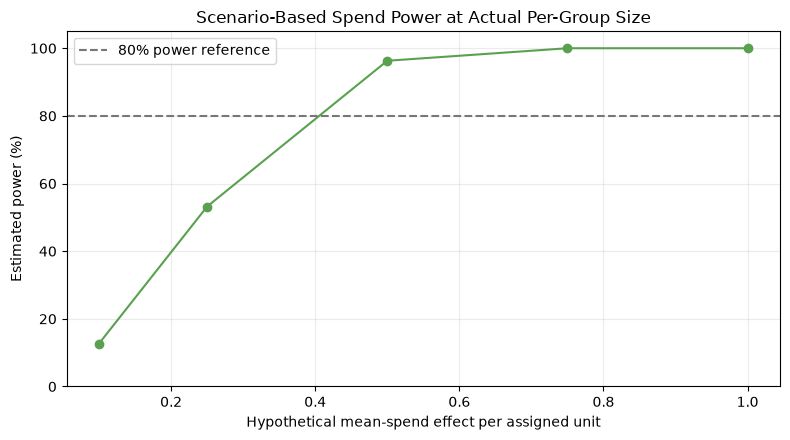

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(spend_simulation['Hypothetical Mean Spend Effect'], spend_simulation['Estimated Power'] * 100, marker='o', color='#59A14F')
ax.axhline(80, color='#777777', linestyle='--', label='80% power reference')
ax.set(title='Scenario-Based Spend Power at Actual Per-Group Size', xlabel='Hypothetical mean-spend effect per assigned unit', ylabel='Estimated power (%)')
ax.set_ylim(0, 105)
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
fig.savefig(figure_dir / 'spend_power_simulation.png', dpi=160, bbox_inches='tight')
plt.show()

## 10. Multiplicity-aware planning sensitivity

Stage 05 used Holm adjustment within outcome families. Planning with alpha = 0.05 per comparison is retained for interpretability. The alpha = 0.025 calculations below are a conservative sensitivity for protecting two primary comparisons, not an exact representation of the step-down Holm procedure.

In [9]:
multiplicity_rows = []
for outcome, baseline_rate in [('Conversion', control_conversion_rate), ('Visit', control_visit_rate)]:
    for alpha_value in [0.05, 0.025]:
        result = binary_mde(baseline_rate, sample_sizes[control_group], sample_sizes['Mens E-Mail'], 0.80, alpha_value)
        multiplicity_rows.append({'Outcome': outcome, 'Planning Alpha': alpha_value, 'Power': 0.80, 'MDE Percentage Points': result['MDE Percentage Points'], 'Relative MDE': result['Relative MDE']})
multiplicity_sensitivity = pd.DataFrame(multiplicity_rows)
display(multiplicity_sensitivity.round(5))

,Outcome,Planning Alpha,Power,MDE Percentage Points,Relative MDE
0,Conversion,0.050,0.8,0.22299,0.38942
1,Conversion,0.025,0.8,0.24740,0.43205
2,Visit,0.050,0.8,0.85055,0.08011
3,Visit,0.025,0.8,0.93759,0.08831


## 11. Planning table and experiment-design interpretation

The planning table provides selected conversion and visit scenarios. Higher desired power and smaller target effects require more observations per group. Low conversion prevalence makes small absolute conversion changes especially sample-intensive. MDE should ideally be set by business relevance before an experiment, because statistical detectability is not the same as business importance.

In [10]:
power_mde_summary = planning_table.copy()
power_mde_summary['Baseline (%)'] = power_mde_summary['Baseline'] * 100
power_mde_summary['Target Absolute Effect (pp)'] = power_mde_summary['Target Absolute Effect'] * 100
power_mde_summary['Target Relative Lift (%)'] = power_mde_summary['Target Relative Lift'] * 100
power_mde_summary = power_mde_summary[['Outcome', 'Baseline (%)', 'Target Absolute Effect (pp)', 'Target Relative Lift (%)', 'Power', 'Alpha', 'Required Sample Size Per Group']]
display(power_mde_summary)
power_mde_summary.to_csv(table_dir / 'power_mde_summary.csv', index=False)
print('Saved outputs/tables/power_mde_summary.csv')

,Outcome,Baseline (%),Target Absolute Effect (pp),Target Relative Lift (%),Power,Alpha,Required Sample Size Per Group
0,Conversion,0.572609,0.10,17.463934,0.8,0.05,96971
1,Conversion,0.572609,0.10,17.463934,0.9,0.05,129816
2,Conversion,0.572609,0.20,34.927869,0.8,0.05,26073
3,Conversion,0.572609,0.20,34.927869,0.9,0.05,34905
4,Conversion,0.572609,0.30,52.391803,0.8,0.05,12377
5,Conversion,0.572609,0.30,52.391803,0.9,0.05,16569
6,Conversion,0.572609,0.50,87.319672,0.8,0.05,5002
7,Conversion,0.572609,0.50,87.319672,0.9,0.05,6697
8,Conversion,0.572609,0.75,130.979508,0.8,0.05,2513
9,Conversion,0.572609,0.75,130.979508,0.9,0.05,3364


Saved outputs/tables/power_mde_summary.csv


## 12. Limitations

The original power calculation, target MDE, and original primary metric are unavailable. This is a retrospective design evaluation using observed control baselines, not a reconstruction of the original protocol. Spend simulation depends on the chosen positive-spend-probability scenario. There is no experiment cost, profit-margin, or customer-lifetime-value information, so an economically optimal sample size cannot be determined.

# Stage 06 Findings

**Conversion:** the control baseline, actual-size 80% and 90% MDEs, relative MDEs, and Stage 05 reference effects are reported above. Low conversion prevalence makes small percentage-point changes sample-intensive.

**Visit:** the corresponding baseline and MDEs show that the current group sizes can detect smaller absolute visit changes than conversion changes, reflecting the higher baseline rate.

**Spend:** control spend has extreme zero inflation and high variability. The scenario-based simulation reports power for hypothetical mean-spend increases under a preserved-positive-spend-distribution mechanism; it is not an exact normal-theory design calculation.

**Planning:** selected sample-size scenarios, the 80% versus 90% tradeoff, and alpha = 0.025 multiplicity sensitivity are shown in the tables and curves. The central experiment-design lesson is to choose a business-relevant effect before running an experiment, then size the study to detect it. No treatment recommendation is made.

## 13. File-integrity confirmation

In [11]:
raw_hash_after = file_sha256(raw_path)
processed_hash_after = file_sha256(processed_path)
print('Raw dataset unchanged during notebook execution:', raw_hash_before == raw_hash_after)
print('Processed dataset unchanged during notebook execution:', processed_hash_before == processed_hash_after)
print('All power calculations use two-sided alpha assumptions and percentage-point labels for binary effects.')

Raw dataset unchanged during notebook execution: True
Processed dataset unchanged during notebook execution: True
All power calculations use two-sided alpha assumptions and percentage-point labels for binary effects.
